# Big Picture of Analytics: End-to-End Machine Learning
### ISA 383: Python for Business  |  American University of Sharjah

**Learning objectives**

- Walk through a realistic enterprise ML pipeline end-to-end --- the same shape used at HP for forecasting 18,000 SKUs across 170 countries, but on a dataset small enough to run in a single notebook.
- Synthesise a small demand panel, save it as **Parquet** (the same family as Apache Feather), validate, and reload it.
- Engineer the families of features that matter for time-series ML: **lags, rolling statistics, product-life-cycle, seasonal dummies**.
- Train a **LightGBM** model with a walk-forward backtest, and compare it against a seasonal-naive baseline.
- Evaluate forecasts with the metrics planners actually care about: **Bias, RMSE, weighted MAPE (wMAPE)**.
- Serialise the trained model with **joblib** so a separate predict job can re-load it tomorrow.
- See how the same notebook would look once *parameterised* with Papermill and tracked with MLflow.

**Philosophy of this lab**

Most analytics courses end at `model.fit()`. In a real company, that line is the middle of a long pipeline: data lake $\to$ extract $\to$ validate $\to$ features $\to$ train $\to$ backtest $\to$ register $\to$ predict $\to$ planning system $\to$ planner $\to$ final forecast. Every box is Python's job, or it talks to Python. This notebook walks through the Python boxes at toy scale.

---

## Using this notebook in Google Colab

1. Before editing, select **File > Save a copy in Drive**.
2. Run the cells in order. Some practice cells intentionally wait for your input.
3. The notebook creates any course folders and teaching files it needs automatically.
4. Files under `/content` are temporary and disappear when the Colab runtime resets.
5. Never paste an API key into a notebook cell. Use the **Secrets** panel when instructed.

You do not need to find, copy, or type a file path for the prepared course data.


## 1. Setup

Run the next cell once. Colab installs LightGBM and PyArrow and creates a temporary working folder automatically. No local environment or path selection is required.


In [ ]:
%pip install -q lightgbm pyarrow

print("Machine-learning packages are ready.")


In [ ]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
import joblib

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.figsize": (9, 4.0), "font.size": 10})

DATA_DIR = Path("/content/isa383/16_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)
print("lightgbm:", lgb.__version__)


## 2. Synthesise a Demand Panel

Real HP demand data is proprietary, so we generate a small **panel** that mimics its shape: a few SKUs, sold in a few countries, observed monthly for several years.

The generator combines four ingredients you would also see in real demand:

1. **Trend** --- a slowly-growing base level for each SKU--country pair.
2. **Seasonality** --- a 12-month cosine wave (Q4 spike for printers, etc.).
3. **Product life-cycle decay** --- newer SKUs ramp up; older SKUs slowly fade.
4. **Multiplicative noise** --- a lognormal shock so the series cannot go negative.

We deliberately keep the panel small (3 SKUs $\times$ 2 countries $\times$ 60 months = 360 rows) so every cell runs in a second or two.

In [2]:
def synth_demand_panel(start="2020-01", n_months=60, seed=42):
    """Synthesise a (sku, country, month) demand panel."""
    rng = np.random.default_rng(seed)

    skus = {
        "PRN-A100": {"base": 800,  "trend": 1.5,  "seas_amp": 220, "launch_idx": 0,  "lifespan": 72},
        "PRN-B200": {"base": 450,  "trend": 0.8,  "seas_amp": 140, "launch_idx": 6,  "lifespan": 60},
        "PRN-C300": {"base": 1200, "trend": -2.0, "seas_amp": 320, "launch_idx": 0,  "lifespan": 48},
    }
    countries = {
        "AE": 1.00,
        "DE": 1.35,
    }

    months = pd.date_range(start=start, periods=n_months, freq="MS")
    rows = []

    for sku, p in skus.items():
        for country, scale in countries.items():
            for t, dt in enumerate(months):
                if t < p["launch_idx"]:
                    demand = 0
                else:
                    age = t - p["launch_idx"]
                    life_left = max(0.0, 1.0 - age / p["lifespan"])
                    trend = p["base"] + p["trend"] * age
                    seas = p["seas_amp"] * np.cos(2 * np.pi * (dt.month - 11) / 12)
                    level = max(0.0, scale * (trend * life_left + seas))
                    noise = rng.lognormal(mean=0.0, sigma=0.15)
                    demand = level * noise
                rows.append({
                    "month": dt,
                    "sku": sku,
                    "country": country,
                    "demand": float(demand),
                })

    return pd.DataFrame(rows)


demand = synth_demand_panel()
print(demand.shape)
demand.head(8)


(360, 4)


,month,sku,country,demand
0,2020-01-01,PRN-A100,AE,952.559109
1,2020-02-01,PRN-A100,AE,676.208266
2,2020-03-01,PRN-A100,AE,750.606344
3,2020-04-01,PRN-A100,AE,668.405173
4,2020-05-01,PRN-A100,AE,403.902971
5,2020-06-01,PRN-A100,AE,461.375472
6,2020-07-01,PRN-A100,AE,643.811483
7,2020-08-01,PRN-A100,AE,697.802494


Quick sanity plot --- the cosine seasonality and the slow life-cycle decay should be visible.

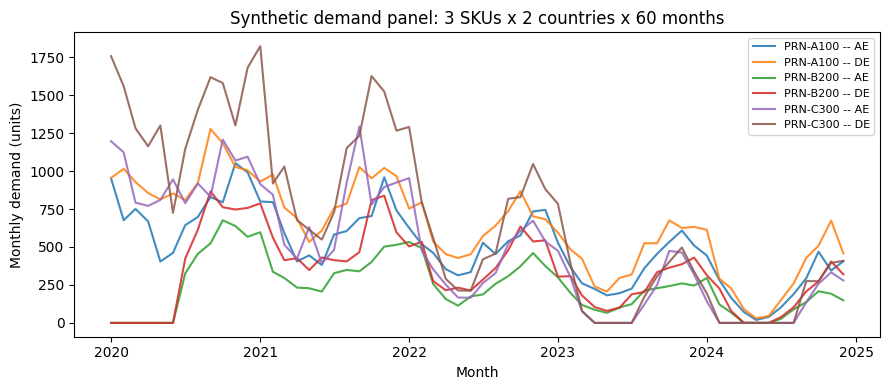

In [3]:
fig, ax = plt.subplots()
for (sku, country), g in demand.groupby(["sku", "country"]):
    ax.plot(g["month"], g["demand"], label=f"{sku} -- {country}", alpha=0.85)
ax.set_xlabel("Month")
ax.set_ylabel("Monthly demand (units)")
ax.set_title("Synthetic demand panel: 3 SKUs x 2 countries x 60 months")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


## 3. Save to Parquet, Reload, Compare with CSV

In production at HP we stopped using CSV (slow, no schema, fragile) and Pickle (version-fragile) in favour of **Apache Feather / Parquet** --- columnar, compressed, and cross-language. Parquet is just the on-disk variant of the same Arrow format that powers Feather. Pandas writes it natively.

In [4]:
parquet_path = DATA_DIR / "demand_toy.parquet"
csv_path     = DATA_DIR / "demand_toy.csv"

demand.to_parquet(parquet_path, index=False)
demand.to_csv(csv_path, index=False)

sizes = {
    "parquet": parquet_path.stat().st_size,
    "csv    ": csv_path.stat().st_size,
}
for k, v in sizes.items():
    print(f"{k}: {v:>6} bytes")
print(f"Parquet is {sizes['csv    '] / sizes['parquet']:.1f}x smaller than CSV.")


parquet:   6370 bytes
csv    :  14387 bytes
Parquet is 2.3x smaller than CSV.


And we reload Parquet with the schema (dtypes!) preserved:

In [5]:
demand_back = pd.read_parquet(parquet_path)
print("dtypes after Parquet round-trip:\n", demand_back.dtypes, sep="")
print("\nMatches original?", demand_back.equals(demand))


dtypes after Parquet round-trip:
month      datetime64[ns]
sku                object
country            object
demand            float64
dtype: object

Matches original? True


## 4. Data Validation

Before we touch a model, we check the data. This is the **Data Validation** box from Figure 2 of the HP paper. In production it would log to MLflow and fail loudly if anything is wrong; here we just print and assert.

In [6]:
def validate_demand_panel(df):
    """Minimal schema and sanity checks. Raises AssertionError on failure."""
    expected = {"month", "sku", "country", "demand"}
    assert expected.issubset(df.columns), f"Missing columns: {expected - set(df.columns)}"
    assert df["demand"].notna().all(), "demand has NaNs"
    assert (df["demand"] >= 0).all(), "negative demand detected"
    assert pd.api.types.is_datetime64_any_dtype(df["month"]), "month is not a datetime"

    # Each (sku, country) must have a contiguous monthly grid
    for (sku, country), g in df.groupby(["sku", "country"]):
        gap = g["month"].diff().dropna().dt.days.unique()
        # Months are 28-31 days; accept any gap in that range
        bad = [d for d in gap if not (27 <= d <= 32)]
        assert not bad, f"Non-monthly gap for {sku}-{country}: {bad}"

    return {
        "n_rows":      len(df),
        "n_skus":      df["sku"].nunique(),
        "n_countries": df["country"].nunique(),
        "min_month":   df["month"].min(),
        "max_month":   df["month"].max(),
    }


report = validate_demand_panel(demand)
report


{'n_rows': 360,
 'n_skus': 3,
 'n_countries': 2,
 'min_month': Timestamp('2020-01-01 00:00:00'),
 'max_month': Timestamp('2024-12-01 00:00:00')}

## 5. Feature Engineering

This is where most of the lift comes from. We build five families of features, mirroring Table 2 of the HP paper:

| Family            | What it captures                              |
|-------------------|-----------------------------------------------|
| Lagged demand     | Past months of demand (the autoregressive part) |
| Rolling stats     | Recent trend + variability (3 / 6 / 12 months) |
| Product life cycle| Fraction of a configured expected lifespan remaining |
| Seasonality       | Calendar month + fiscal quarter                |
| Group statistics  | Historical mean demand per SKU and per country |

Each function takes the panel and returns it with new columns added. Keeping the pipeline as a chain of small functions is what makes it testable later.

In [ ]:
def add_lags(df, lags=(1, 2, 3, 6, 12)):
    df = df.sort_values(["sku", "country", "month"]).copy()
    for L in lags:
        df[f"lag_{L}"] = df.groupby(["sku", "country"])["demand"].shift(L)
    return df


def add_rolling(df, windows=(3, 6, 12)):
    df = df.sort_values(["sku", "country", "month"]).copy()
    grp = df.groupby(["sku", "country"])["demand"].shift(1)  # avoid leakage: roll on lagged
    for w in windows:
        df[f"roll_mean_{w}"] = grp.groupby([df["sku"], df["country"]]).transform(
            lambda x: x.rolling(w, min_periods=1).mean())
        df[f"roll_std_{w}"]  = grp.groupby([df["sku"], df["country"]]).transform(
            lambda x: x.rolling(w, min_periods=1).std())
    return df


def add_seasonality(df):
    df = df.copy()
    df["month_num"]   = df["month"].dt.month
    df["quarter"]     = df["month"].dt.quarter
    df["month_in_q"]  = ((df["month"].dt.month - 1) % 3) + 1
    df["month_sin"]   = np.sin(2 * np.pi * df["month_num"] / 12)
    df["month_cos"]   = np.cos(2 * np.pi * df["month_num"] / 12)
    return df


def add_lifecycle(df, expected_life_months=60):
    """Encode age and remaining life using a lifespan known before forecasting."""
    df = df.sort_values(["sku", "country", "month"]).copy()
    df["age_m"] = df.groupby(["sku", "country"]).cumcount()
    denominator = max(expected_life_months - 1, 1)
    df["life_remaining"] = (1.0 - df["age_m"] / denominator).clip(lower=0)
    return df


def add_group_stats(df):
    """Add expanding means computed only from months before each row."""
    df = df.copy()

    sku_month = (df.groupby(["sku", "month"], as_index=False)["demand"]
                   .mean().sort_values(["sku", "month"]))
    sku_month["sku_mean_demand"] = sku_month.groupby("sku")["demand"].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean())

    country_month = (df.groupby(["country", "month"], as_index=False)["demand"]
                       .mean().sort_values(["country", "month"]))
    country_month["country_mean_demand"] = country_month.groupby("country")["demand"].transform(
        lambda s: s.shift(1).expanding(min_periods=1).mean())

    df = df.merge(sku_month[["sku", "month", "sku_mean_demand"]],
                  on=["sku", "month"], how="left", validate="many_to_one")
    df = df.merge(country_month[["country", "month", "country_mean_demand"]],
                  on=["country", "month"], how="left", validate="many_to_one")
    return df


def build_features(df):
    df = add_lags(df)
    df = add_rolling(df)
    df = add_seasonality(df)
    df = add_lifecycle(df)
    df = add_group_stats(df)
    return df


feat = build_features(demand)
print("Feature matrix:", feat.shape)
feat.head(15)


Note the early rows have `NaN` lags --- there is no demand "before" January 2020. We drop them when training.

In [8]:
# Encode categoricals as integer codes (LightGBM accepts pandas categoricals natively)
feat["sku"]     = feat["sku"].astype("category")
feat["country"] = feat["country"].astype("category")

print("Rows with any NaN in lag features:",
      feat[[c for c in feat.columns if c.startswith("lag_")]].isna().any(axis=1).sum())


Rows with any NaN in lag features: 72


## 6. Walk-Forward Backtest

A normal `train_test_split` would leak future information into the training set. For time series we use a **walk-forward** scheme: train on everything before month $t$, predict month $t$, slide the window forward, repeat. This is a simplified version of the *iterative forecasting algorithm* in the HP paper.

In [9]:
FEATURE_COLS = [
    "sku", "country",
    "lag_1", "lag_2", "lag_3", "lag_6", "lag_12",
    "roll_mean_3", "roll_mean_6", "roll_mean_12",
    "roll_std_3",  "roll_std_6",  "roll_std_12",
    "month_num", "quarter", "month_in_q", "month_sin", "month_cos",
    "life_remaining", "age_m",
    "sku_mean_demand", "country_mean_demand",
]
TARGET = "demand"


def walk_forward_backtest(feat, n_test_months=12, model_kwargs=None):
    """Walk-forward backtest. Returns a DataFrame of (month, sku, country, y_true, y_pred)."""
    model_kwargs = model_kwargs or dict(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        min_data_in_leaf=5,
        verbose=-1,
    )

    months = sorted(feat["month"].unique())
    test_months = months[-n_test_months:]
    rows = []

    for t in test_months:
        train = feat[feat["month"] < t].dropna(subset=["lag_12"])
        test  = feat[feat["month"] == t]

        X_train, y_train = train[FEATURE_COLS], train[TARGET]
        X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

        model = lgb.LGBMRegressor(**model_kwargs)
        model.fit(X_train, y_train, categorical_feature=["sku", "country"])

        y_pred = model.predict(X_test)
        for r, yhat in zip(test.itertuples(), y_pred):
            rows.append({
                "month":   r.month,
                "sku":     r.sku,
                "country": r.country,
                "y_true":  r.demand,
                "y_pred":  float(yhat),
            })

    return pd.DataFrame(rows), model  # return last model too


bt, last_model = walk_forward_backtest(feat, n_test_months=12)
bt.head()


,month,sku,country,y_true,y_pred
0,2024-01-01,PRN-A100,AE,443.619344,337.568274
1,2024-01-01,PRN-A100,DE,613.561583,532.779540
2,2024-01-01,PRN-B200,AE,295.976634,169.904301
3,2024-01-01,PRN-B200,DE,314.766773,347.784340
4,2024-01-01,PRN-C300,AE,142.695820,240.076337


## 7. Evaluation: Bias, RMSE, wMAPE

The three metrics planners actually live with:

- **Bias** $= \text{mean}(\hat y - y) / \text{mean}(y)$. Negative = under-forecast, positive = over-forecast.
- **RMSE** $= \sqrt{\text{mean}((\hat y - y)^2)}$. Penalises large misses.
- **wMAPE** $= \sum |\hat y - y| / \sum |y|$. The headline KPI in supply chain.

In [10]:
def bias(y_true, y_pred):
    return float(np.mean(y_pred - y_true) / np.mean(y_true))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

def wmape(y_true, y_pred):
    return float(np.sum(np.abs(y_pred - y_true)) / np.sum(np.abs(y_true)))


def score(df, label):
    return pd.Series({
        "Bias":  bias(df["y_true"], df["y_pred"]),
        "RMSE":  rmse(df["y_true"], df["y_pred"]),
        "wMAPE": wmape(df["y_true"], df["y_pred"]),
    }, name=label)


score(bt, "LightGBM")


Bias      0.028548
RMSE     73.197585
wMAPE     0.318227
Name: LightGBM, dtype: float64

### A naive baseline to compare against

The toy stand-in for HP's *Statistical* model: a **seasonal-naive forecast** that simply repeats the demand from 12 months ago. If LightGBM cannot beat this, we have done something very wrong.

In [11]:
# y_pred = lag_12 = demand 12 months ago
naive = feat.dropna(subset=["lag_12"]).copy()
naive = naive[naive["month"].isin(bt["month"].unique())]
naive_bt = naive.rename(columns={"demand": "y_true", "lag_12": "y_pred"})[
    ["month", "sku", "country", "y_true", "y_pred"]
]

results = pd.concat([
    score(naive_bt, "Seasonal-Naive"),
    score(bt,        "LightGBM"),
], axis=1).T

results.style.format({
    "Bias":  "{:+.2%}",
    "RMSE":  "{:.1f}",
    "wMAPE": "{:.2%}",
})


,Bias,RMSE,wMAPE
Seasonal-Naive,+64.14%,152.3,66.81%
LightGBM,+2.85%,73.2,31.82%


LightGBM should clearly beat the seasonal-naive on wMAPE and RMSE. This is the same pattern as Table 3 of the HP paper, where the ML model halved the wMAPE of the statistical baseline at CM3 / CM6.

### wMAPE over rolling evaluation windows

Each test prediction above is one month ahead. Aggregating those errors over rolling 1-, 3-, and 6-month evaluation windows shows how the reported error changes with the reporting window, but it does **not** create genuine 3- or 6-month-ahead forecast-horizon metrics. We therefore label the columns W1, W3, and W6 rather than CM1, CM3, and CM6.

In [ ]:
def window_wmape(df, k):
    """Average wMAPE across rolling k-month evaluation windows."""
    df = df.sort_values("month").copy()
    months = sorted(df["month"].unique())
    if len(months) < k:
        return np.nan
    out = []
    for i in range(0, len(months) - k + 1):
        window = df[df["month"].isin(months[i : i + k])]
        out.append(wmape(window["y_true"], window["y_pred"]))
    return float(np.mean(out))


windows = [1, 3, 6]
window_table = pd.DataFrame({
    f"W{k}": [
        window_wmape(naive_bt, k),
        window_wmape(bt,       k),
    ]
    for k in windows
}, index=["Seasonal-Naive", "LightGBM"])

window_table.style.format("{:.2%}")


### Visual: forecast vs actuals, one series at a time

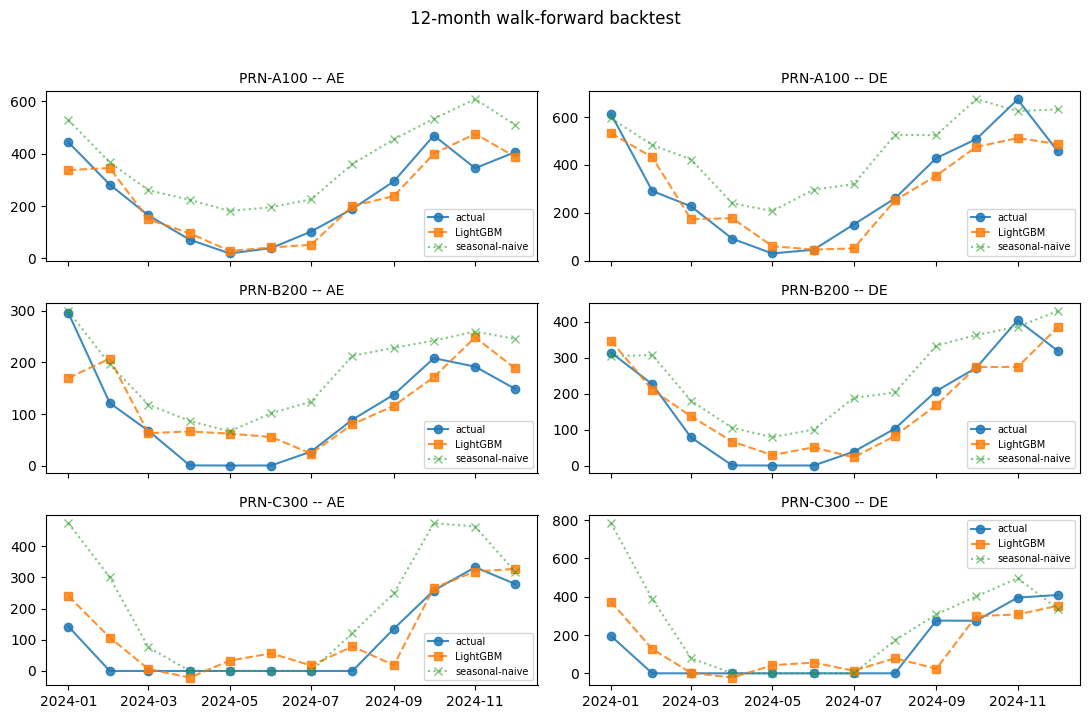

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(11, 7), sharex=True)
for ax, ((sku, country), g_true) in zip(axes.flat, bt.groupby(["sku", "country"])):
    ax.plot(g_true["month"], g_true["y_true"], "o-", label="actual",     alpha=0.85)
    ax.plot(g_true["month"], g_true["y_pred"], "s--", label="LightGBM",  alpha=0.85)
    nb = naive_bt[(naive_bt["sku"] == sku) & (naive_bt["country"] == country)]
    ax.plot(nb["month"], nb["y_pred"], "x:", label="seasonal-naive", alpha=0.6)
    ax.set_title(f"{sku} -- {country}", fontsize=10)
    ax.legend(fontsize=7, loc="best")
plt.suptitle("12-month walk-forward backtest", y=1.02)
plt.tight_layout()
plt.show()


## 8. Reproducibility: Save the Model and the Data

Once a model wins the backtest, it gets serialised. In HP we used MLflow's model registry; for a toy notebook, **`joblib.dump`** is enough. The point is that someone running a separate `predict.py` tomorrow can re-load *exactly* this model.

In [ ]:
MODEL_PATH = DATA_DIR / "lightgbm_demand.joblib"
joblib.dump(last_model, MODEL_PATH)
print(f"Saved model to {MODEL_PATH} ({MODEL_PATH.stat().st_size / 1024:.1f} KB)")

# And reload it
loaded = joblib.load(MODEL_PATH)
sample = feat.dropna(subset=["lag_12"]).iloc[-3:]
print("\nReloaded model predictions on last 3 rows:")
print(loaded.predict(sample[FEATURE_COLS]))


In [ ]:
# @title Download the generated data and trained model (optional)
DOWNLOAD_ARTIFACTS = False  # @param {type:"boolean"}

if DOWNLOAD_ARTIFACTS:
    import shutil
    from google.colab import files

    archive_base = "/content/isa383_ml_artifacts"
    archive_path = shutil.make_archive(archive_base, "zip", DATA_DIR)
    files.download(archive_path)
else:
    print("Set DOWNLOAD_ARTIFACTS to True and rerun this cell when you want a ZIP file.")


### Reproducibility patterns we did *not* run live

A real production pipeline adds two more layers. We sketch them in code so you know what they look like, but we do not execute them here (they assume MLflow / Papermill installed and an orchestrator).

**MLflow tracking** wraps every run with parameters, metrics, and artefacts:

```python
import mlflow

mlflow.set_experiment("isa383-demand-toy")
with mlflow.start_run(run_name="lightgbm-baseline"):
    mlflow.log_params({"n_estimators": 300, "num_leaves": 31, "lr": 0.05})
    # ... fit model ...
    mlflow.log_metric("wMAPE_W3", float(window_table.loc["LightGBM", "W3"]))
    mlflow.log_artifact(str(MODEL_PATH))
```

**Papermill** turns this notebook into a function. Tag a cell at the top with `parameters` and you can invoke it from anywhere:

```python
# Cell tagged `parameters`
country     = "AE"
n_test      = 12
model_seed  = 42
```

Then from `orchestrator.py`:

```python
import papermill as pm

for country in ["AE", "DE"]:
    pm.execute_notebook(
        "16_End_to_End_ML.ipynb",
        f"runs/{country}.ipynb",
        parameters={"country": country, "n_test": 12},
    )
```

The same notebook is now reproducible per country, with an audit trail (one saved notebook per run).

## 9. From Notebook to Production

What changes when this notebook becomes a monthly production job? About six things:

| In the notebook                  | In production                                            |
|----------------------------------|----------------------------------------------------------|
| One CSV / one DataFrame          | Monthly Parquet extracts from a data lake (Snowflake / S3) |
| Hard-coded hyper-parameters      | Pulled from a `config.yaml` per business segment         |
| Cells run by hand                | Notebook called by Papermill from an orchestrator (Airflow / Prefect / cron) |
| `joblib.dump`                    | `mlflow.lightgbm.log_model` to a registry                |
| `print` for inspection            | Structured logs + alerts (Sentry / Datadog)              |
| Plot in the notebook              | Tableau / Power BI dashboard reading from the predictions table |

None of those changes the *Python* in any deep way. They change the **plumbing around the Python**. Mastering that plumbing is what separates a junior who can finish a Kaggle notebook from a senior who can ship a forecast that the supply chain depends on.

## 10. Summary

1. **The shape of an enterprise pipeline** is: extract $\to$ validate $\to$ feature $\to$ train $\to$ backtest $\to$ register $\to$ predict $\to$ planning system. Every box is a few cells of Python.
2. **Parquet beats CSV** on size, speed, and schema fidelity. Make it your default.
3. **Validation comes before modelling.** A schema check is twenty lines of code and it stops most production fires.
4. **Time-aware backtests** such as walk-forward evaluation preserve temporal order. Random splits are usually inappropriate when they allow future observations to inform earlier predictions.
5. **wMAPE, RMSE, Bias** are the metrics planners care about. RMSE for training, wMAPE for reporting.
6. **LightGBM with sensible features** can outperform simple statistical baselines on tabular business data, but the comparison must be verified on an appropriate backtest.
7. **Joblib + Parquet + a config file** is enough reproducibility for a course project. **MLflow + Papermill + git + a registry** is what you graduate to in industry.
8. The hard part of enterprise ML is the *plumbing*, not the model. The model is sometimes one line.

## 11. Exercises

1. **Add a third country.** Extend `synth_demand_panel` to include `"JP"` with a scale factor of `0.7`. Re-run the full pipeline and report the updated W1/W3/W6 evaluation-window table.

2. **Swap the model.** Replace `lgb.LGBMRegressor` with `sklearn.ensemble.RandomForestRegressor`, using a comparable computational budget and a fixed random seed. Compare W3 wMAPE. Which model performs better on this data, and why might that result occur?

3. **Tighten the rolling window.** Change `windows=(3, 6, 12)` to `windows=(3, 6)` (drop the 12-month roll). Recompute wMAPE. Does removing the long window help or hurt? Why?

4. **Direct vs iterated forecasting.** Modify the backtest so it forecasts 3 months at once (i.e. one model that predicts $t+1, t+2, t+3$ in a single call) instead of one month at a time. Compare to the iterated approach above. Which gives lower wMAPE? Discuss the bias--variance trade-off this exposes (see Marcellino, Stock, Watson 2006).

5. **Feature ablation.** Drop the `life_remaining` and `age_m` columns from `FEATURE_COLS` and rerun. How does wMAPE change? What does this suggest about the value of life-cycle information in this synthetic dataset?

6. **Optional --- Hyperopt.** If you have `hyperopt` installed, wrap the LightGBM training in a 30-trial Bayesian search over `num_leaves`, `min_data_in_leaf`, and `learning_rate`. How much does the final wMAPE improve over the defaults? Was it worth the compute?

---

*Submit your completed notebook by the deadline in the course schedule for Participation credit.*